# CBAM Architecture

## Explainable Hybrid Deep Learning Framework for Multi-Class Dementia Detection using Brain MRI Images

Today we integrate the Convolutional Block Attention Module (CBAM) into the EfficientNetV2B0 baseline model.

Objective:

- Understand CBAM
- Validate implementation
- Verify architecture
- Compare parameter counts
- Verify forward pass

No training is performed in this notebook.

In [1]:
from pathlib import Path
import sys

# Project root directory
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: g:\Projects\DementiaDetection


In [2]:
from src.models.cbam import (
    ChannelAttention,
    SpatialAttention,
    CBAM,
)

from src.models.efficientnet import (
    build_efficientnet_model,
)

from src.models.efficientnet_cbam import (
    build_efficientnet_cbam,
)

from src.training.compile import (
    compile_model,
)

In [3]:
baseline_model = build_efficientnet_model()

baseline_model = compile_model(
    baseline_model,
)

baseline_model.summary()

Model: "efficientnetv2b0_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,924,436 (22.60 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [4]:
cbam_model = build_efficientnet_cbam()

cbam_model = compile_model(
    cbam_model,
)

cbam_model.summary()

Model: "EfficientNetV2B0_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam (CBAM)                     │ (None, 7, 7, 1280)     │       206,258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,130,694 (23.39 MB)

 Trainable params: 211,382 (825.71 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [5]:
baseline_model.count_params()

5924436

In [6]:
cbam_model.count_params()

6130694

In [7]:
print("Baseline")

baseline_model.trainable_weights

Baseline


[<Variable path=predictions/kernel, shape=(1280, 4), dtype=float32, value=[[-0.01504119  0.02021079  0.01642117  0.01090669]
  [ 0.04964831  0.04786751  0.04468506 -0.06282402]
  [-0.02544626 -0.02323504  0.05889361  0.03890397]
  ...
  [-0.03997402 -0.03450747  0.01078498 -0.01871173]
  [ 0.02775262 -0.00139869  0.00442696  0.01756568]
  [-0.04953323  0.0562354   0.03405597  0.002009  ]]>,
 <Variable path=predictions/bias, shape=(4,), dtype=float32, value=[0. 0. 0. 0.]>]

In [8]:
print("CBAM")

cbam_model.trainable_weights

CBAM


[<Variable path=cbam/channel_attention/shared_mlp/channel_fc1/kernel, shape=(1280, 80), dtype=float32, value=[[ 0.04239234  0.0472964  -0.00220669 ...  0.05026759 -0.0320192
   -0.04970584]
  [ 0.0216452   0.05524037  0.00720267 ...  0.05774146  0.01966002
   -0.02342788]
  [-0.00859529  0.01662045 -0.0275748  ... -0.05433322 -0.00164017
   -0.01480664]
  ...
  [ 0.03141863  0.04757849  0.0570246  ...  0.04533368  0.04499014
   -0.01295028]
  [ 0.04130891  0.00153223 -0.06020023 ... -0.01069891  0.04265841
   -0.02141919]
  [-0.03255403  0.01816349  0.05162561 ...  0.02508228 -0.01998147
    0.05767483]]>,
 <Variable path=cbam/channel_attention/shared_mlp/channel_fc1/bias, shape=(80,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]>,
 <Variable path=cbam/channel_atten

In [9]:
trainable = sum(
    w.shape.num_elements()
    for w in cbam_model.trainable_weights
)

non_trainable = sum(
    w.shape.num_elements()
    for w in cbam_model.non_trainable_weights
)

print(trainable)
print(non_trainable)

211382
5919312


In [10]:
import tensorflow as tf

dummy = tf.random.normal(
    (1,224,224,3)
)

output = cbam_model(dummy)

print(dummy.shape)

print(output.shape)

(1, 224, 224, 3)
(1, 4)


In [11]:
for layer in cbam_model.layers:

    print(layer.name)

input_image
efficientnetv2-b0
cbam
global_average_pooling
dropout
classifier


MRI Image

↓

EfficientNetV2B0

↓

CBAM

├── Channel Attention

└── Spatial Attention

↓

GlobalAveragePooling

↓

Dropout

↓

Dense(4)

↓

Softmax

## Conclusion

Today's implementation successfully integrates CBAM into the EfficientNetV2B0 backbone.

Key observations:

- ChannelAttention implemented from scratch
- SpatialAttention implemented from scratch
- CBAM integrated successfully
- Model compiled successfully
- Parameter increase is approximately 206K
- Feature map dimensions remain unchanged
- Architecture is ready for training

The next step is training and evaluating the CBAM-enhanced model.

# Training Summary

The EfficientNetV2 + CBAM model was trained using transfer learning.

Training Configuration:

- Backbone: EfficientNetV2B0 (Frozen)
- Attention Module: CBAM
- Input Size: 224 × 224 × 3
- Batch Size: 32
- Epochs: 20
- Optimizer: Adam
- Learning Rate: 0.001
- Loss Function: Sparse Categorical Crossentropy
- Metric: Accuracy

The best model was automatically saved using ModelCheckpoint.
Training history was logged using CSVLogger.

In [4]:
from pathlib import Path

import pandas as pd

history_path = Path("../outputs/efficientnet_cbam_history.csv")

history_df = pd.read_csv(history_path)

history_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.568563,0.937444,0.67800,0.696640,0.001
1,0.645938,0.773726,0.71850,0.623905,0.001
2,0.671656,0.720407,0.71575,0.605448,0.001
3,0.685250,0.687235,0.73075,0.581805,0.001
4,0.698812,0.662807,0.76000,0.553980,0.001


In [5]:
last_epoch = history_df.iloc[-1]

print(f"Training Accuracy      : {last_epoch['accuracy']:.4f}")
print(f"Training Loss          : {last_epoch['loss']:.4f}")
print(f"Validation Accuracy    : {last_epoch['val_accuracy']:.4f}")
print(f"Validation Loss        : {last_epoch['val_loss']:.4f}")

Training Accuracy      : 0.7933
Training Loss          : 0.4780
Validation Accuracy    : 0.8605
Validation Loss        : 0.3335


In [6]:
best_epoch = history_df["val_accuracy"].idxmax()

best = history_df.iloc[best_epoch]

print(f"Best Epoch             : {best_epoch + 1}")
print(f"Training Accuracy      : {best['accuracy']:.4f}")
print(f"Training Loss          : {best['loss']:.4f}")
print(f"Validation Accuracy    : {best['val_accuracy']:.4f}")
print(f"Validation Loss        : {best['val_loss']:.4f}")

Best Epoch             : 20
Training Accuracy      : 0.7933
Training Loss          : 0.4780
Validation Accuracy    : 0.8605
Validation Loss        : 0.3335


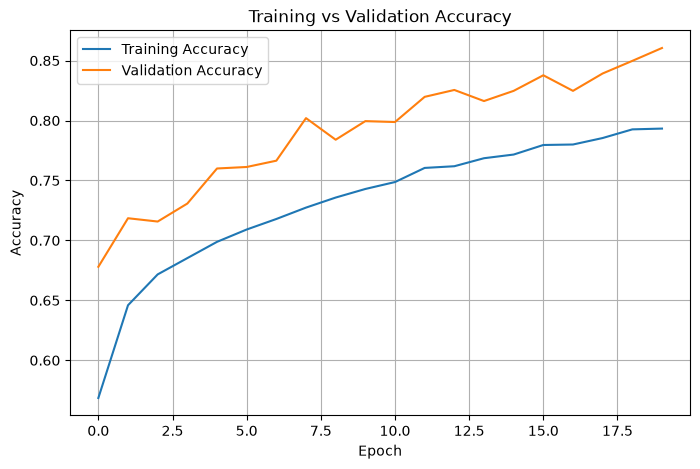

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

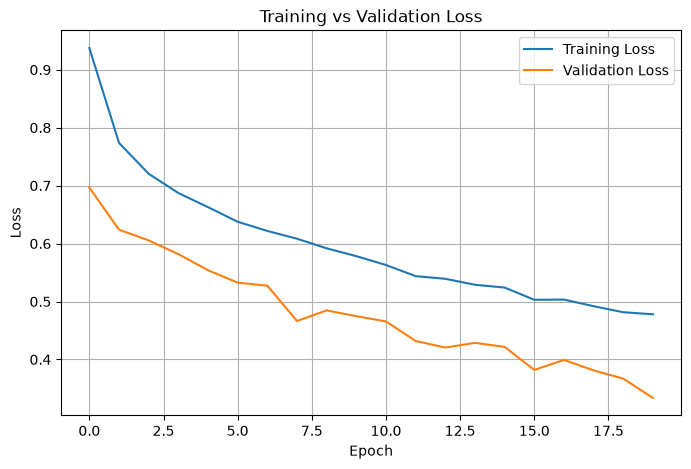

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()